In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
customers = pd.read_csv("customers-1.csv")
products = pd.read_csv("products.csv")
sales = pd.read_csv("sales.csv")

print("Customers:", customers.shape)
print("Products:", products.shape)
print("Sales:", sales.shape)

Customers: (100, 8)
Products: (60, 6)
Sales: (150, 6)


In [5]:
print("Customers columns:", customers.columns.tolist())
print("Products columns:", products.columns.tolist())
print("Sales columns:", sales.columns.tolist())

Customers columns: ['customer_id', 'first_name', 'last_name', 'age', 'state', 'income', 'registration_date', 'email']
Products columns: ['product_id', 'product_name', 'category', 'price', 'launch_date', 'brand']
Sales columns: ['sale_id', 'customer_id', 'product_id', 'transaction_date', 'quantity', 'total_amount']


In [6]:
sales_products = sales.merge(products, on="product_id", how="left")

category_revenue = (
    sales_products.groupby("category")["total_amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue

,category,total_amount
0,Sports & Outdoors,3544.64
1,Electronics,3524.29
2,Clothing,2745.39
3,Accessories,2053.25
4,Home & Garden,1541.46


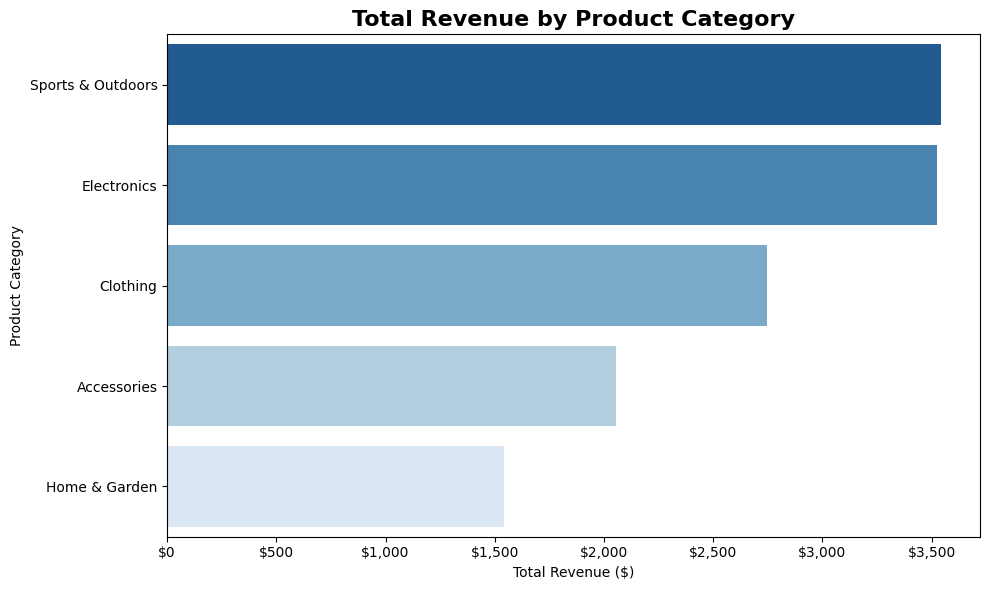

In [7]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_revenue,
    x="total_amount",
    y="category",
    hue="category",
    palette="Blues_r",
    legend=False
)

plt.title("Total Revenue by Product Category", fontsize=16, fontweight="bold")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Product Category")

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, position: f"${value:,.0f}")
)

plt.tight_layout()
plt.show()

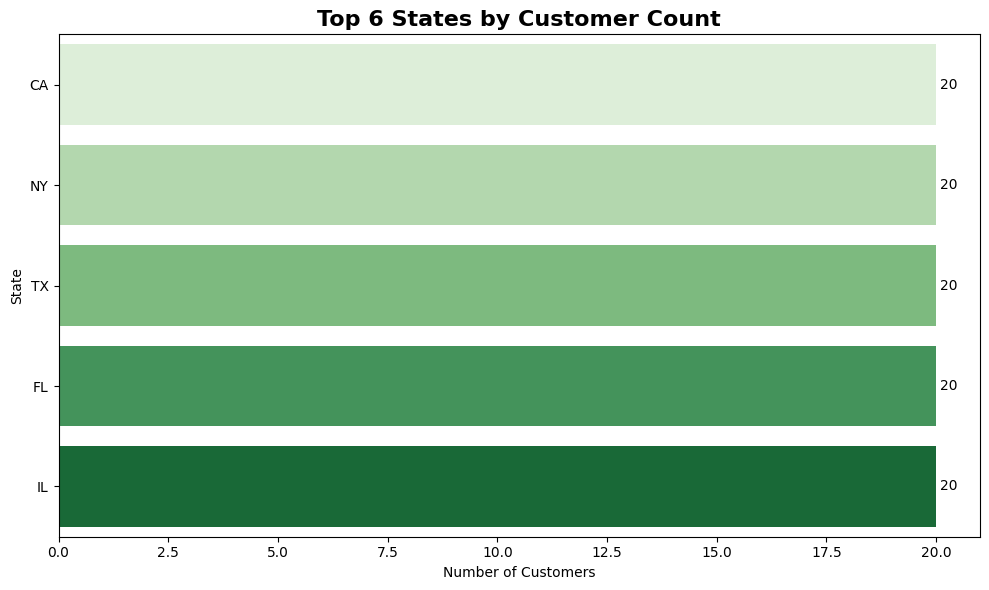

In [8]:
state_counts = (
    customers["state"]
    .value_counts()
    .head(6)
    .sort_values(ascending=True)
    .reset_index()
)

state_counts.columns = ["state", "customer_count"]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=state_counts,
    x="customer_count",
    y="state",
    hue="state",
    palette="Greens",
    legend=False
)

plt.title("Top 6 States by Customer Count", fontsize=16, fontweight="bold")
plt.xlabel("Number of Customers")
plt.ylabel("State")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

In [9]:
# Calculate each customer's total spending and purchase count
customer_spending = (
    sales.groupby("customer_id")
    .agg(
        total_spending=("total_amount", "sum"),
        purchase_count=("sale_id", "count")
    )
    .reset_index()
)

customer_analysis = customers.merge(
    customer_spending,
    on="customer_id",
    how="left"
)

# Include customers with no purchases
customer_analysis[["total_spending", "purchase_count"]] = (
    customer_analysis[["total_spending", "purchase_count"]].fillna(0)
)

# Create age groups
customer_analysis["age_group"] = pd.cut(
    customer_analysis["age"],
    bins=[0, 29, 45, 60, float("inf")],
    labels=["Under 30", "30–45", "46–60", "Over 60"]
)

customer_analysis.head()

,customer_id,first_name,last_name,age,state,income,registration_date,email,total_spending,purchase_count,age_group
0,1,John,Smith,34,CA,75000,2022-01-15,john.smith@email.com,229.98,2.0,30–45
1,2,Sarah,Johnson,28,NY,82000,2022-01-22,sarah.johnson@email.com,179.96,2.0,Under 30
2,3,Michael,Brown,45,TX,95000,2022-02-03,michael.brown@email.com,154.98,2.0,30–45
3,4,Emily,Davis,31,FL,68000,2022-02-14,emily.davis@email.com,234.95,2.0,30–45
4,5,David,Wilson,52,IL,110000,2022-02-28,david.wilson@email.com,149.98,2.0,46–60


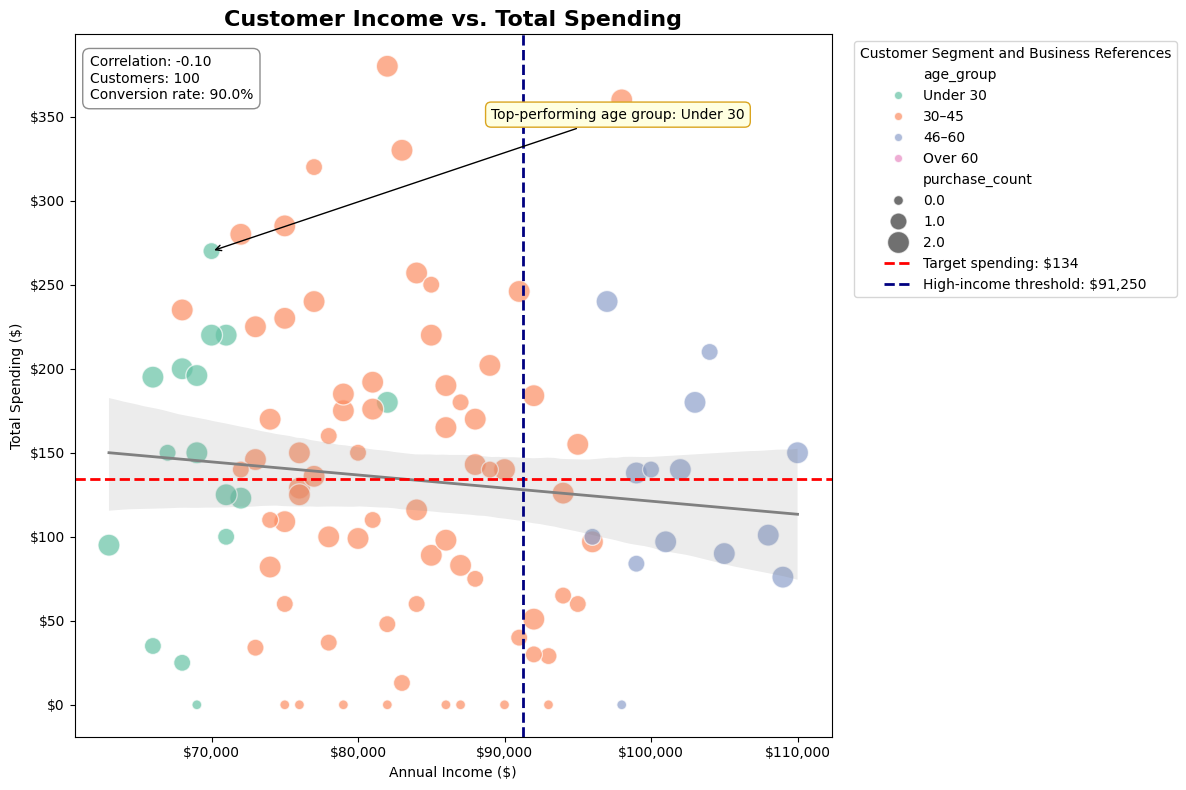

In [10]:
# Business and statistical metrics
correlation = customer_analysis["income"].corr(
    customer_analysis["total_spending"]
)

customer_count = len(customer_analysis)

conversion_rate = (
    customer_analysis["purchase_count"].gt(0).mean() * 100
)

target_spending = customer_analysis["total_spending"].mean()
high_income = customer_analysis["income"].quantile(0.75)

age_performance = (
    customer_analysis.groupby("age_group", observed=True)["total_spending"]
    .mean()
    .sort_values(ascending=False)
)

top_age_group = age_performance.index[0]

top_customer = (
    customer_analysis[
        customer_analysis["age_group"] == top_age_group
    ]
    .sort_values("total_spending", ascending=False)
    .iloc[0]
)

# Create visualization
plt.figure(figsize=(12, 8))
ax = plt.gca()

sns.scatterplot(
    data=customer_analysis,
    x="income",
    y="total_spending",
    hue="age_group",
    size="purchase_count",
    sizes=(50, 250),
    alpha=0.7,
    palette="Set2",
    ax=ax
)

# Regression line with confidence interval
sns.regplot(
    data=customer_analysis,
    x="income",
    y="total_spending",
    scatter=False,
    color="gray",
    line_kws={"linewidth": 2},
    ax=ax
)

# Business reference lines
ax.axhline(
    target_spending,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Target spending: ${target_spending:,.0f}"
)

ax.axvline(
    high_income,
    color="navy",
    linestyle="--",
    linewidth=2,
    label=f"High-income threshold: ${high_income:,.0f}"
)

# Metrics box using relative coordinates
metrics_text = (
    f"Correlation: {correlation:.2f}\n"
    f"Customers: {customer_count}\n"
    f"Conversion rate: {conversion_rate:.1f}%"
)

ax.text(
    0.02,
    0.97,
    metrics_text,
    transform=ax.transAxes,
    verticalalignment="top",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "white",
        "edgecolor": "gray",
        "alpha": 0.9
    }
)

# Top-performing age-group callout
ax.annotate(
    f"Top-performing age group: {top_age_group}",
    xy=(top_customer["income"], top_customer["total_spending"]),
    xytext=(0.55, 0.88),
    textcoords="axes fraction",
    arrowprops={"arrowstyle": "->", "color": "black"},
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "lightyellow",
        "edgecolor": "goldenrod"
    }
)

ax.set_title(
    "Customer Income vs. Total Spending",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("Annual Income ($)")
ax.set_ylabel("Total Spending ($)")

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, position: f"${value:,.0f}")
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, position: f"${value:,.0f}")
)

ax.legend(
    title="Customer Segment and Business References",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

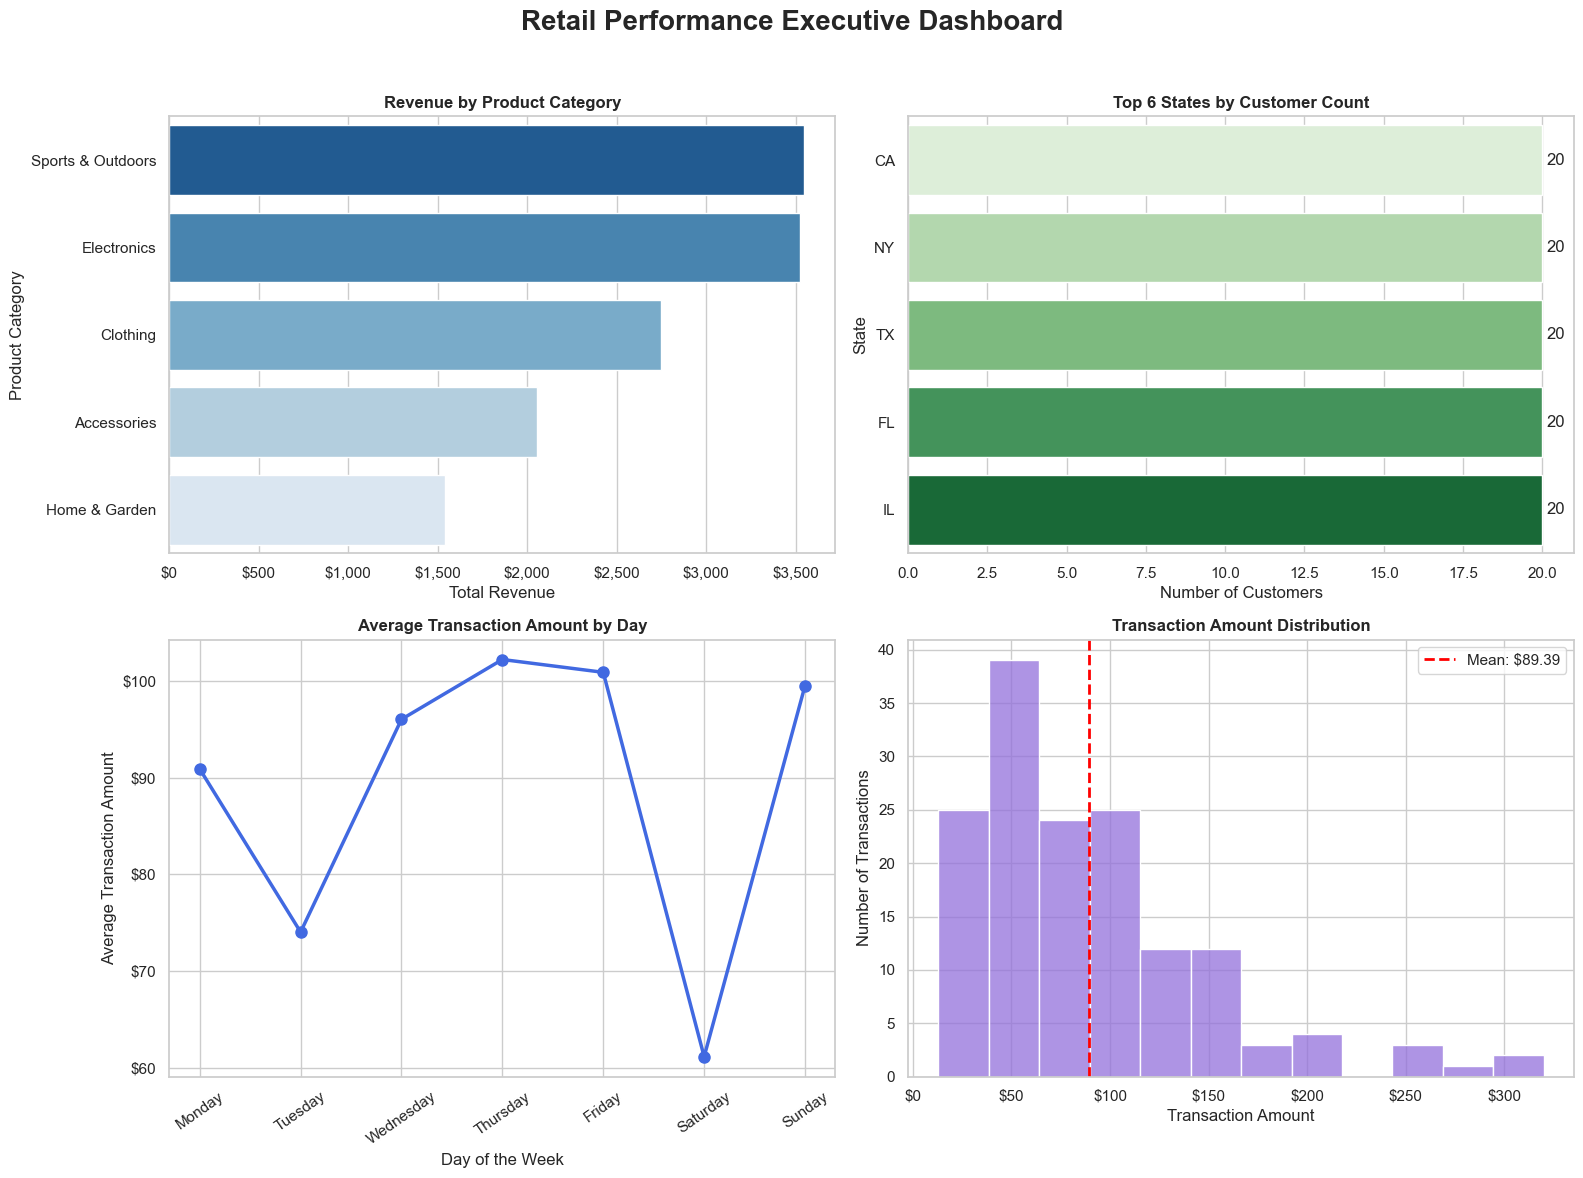

In [11]:
# Prepare Chart 3 data
sales["transaction_date"] = pd.to_datetime(sales["transaction_date"])
sales["day_of_week"] = sales["transaction_date"].dt.day_name()

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

daily_average = (
    sales.groupby("day_of_week")["total_amount"]
    .mean()
    .reindex(day_order)
)

# Prepare Chart 4 metric
mean_transaction = sales["total_amount"].mean()

# Create 2x2 dashboard
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Revenue by Product Category
sns.barplot(
    data=category_revenue,
    x="total_amount",
    y="category",
    hue="category",
    palette="Blues_r",
    legend=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Revenue by Product Category",
    fontweight="bold"
)
axes[0, 0].set_xlabel("Total Revenue")
axes[0, 0].set_ylabel("Product Category")
axes[0, 0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, position: f"${value:,.0f}")
)

# Chart 2: Customer Distribution by State
sns.barplot(
    data=state_counts,
    x="customer_count",
    y="state",
    hue="state",
    palette="Greens",
    legend=False,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Top 6 States by Customer Count",
    fontweight="bold"
)
axes[0, 1].set_xlabel("Number of Customers")
axes[0, 1].set_ylabel("State")

for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, padding=3)

# Chart 3: Daily Transaction Patterns
axes[1, 0].plot(
    daily_average.index,
    daily_average.values,
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="royalblue"
)

axes[1, 0].set_title(
    "Average Transaction Amount by Day",
    fontweight="bold"
)
axes[1, 0].set_xlabel("Day of the Week")
axes[1, 0].set_ylabel("Average Transaction Amount")
axes[1, 0].tick_params(axis="x", rotation=35)
axes[1, 0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, position: f"${value:,.0f}")
)

# Chart 4: Transaction Amount Distribution
sns.histplot(
    data=sales,
    x="total_amount",
    bins=12,
    color="mediumpurple",
    edgecolor="white",
    ax=axes[1, 1]
)

axes[1, 1].axvline(
    mean_transaction,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: ${mean_transaction:,.2f}"
)

axes[1, 1].set_title(
    "Transaction Amount Distribution",
    fontweight="bold"
)
axes[1, 1].set_xlabel("Transaction Amount")
axes[1, 1].set_ylabel("Number of Transactions")
axes[1, 1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, position: f"${value:,.0f}")
)
axes[1, 1].legend()

fig.suptitle(
    "Retail Performance Executive Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()